In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
np.random.seed(42)

data = pd.DataFrame({
    "Math_Score": np.random.normal(70, 10, 50),
    "Science_Score": np.random.normal(75, 8, 50),
    "Study_Hours": np.random.normal(5, 1.5, 50)
})

data.head()

,Math_Score,Science_Score,Study_Hours
0,74.967142,77.592672,2.876944
1,68.617357,71.919342,4.369032
2,76.476885,69.584624,4.485928
3,85.230299,79.893410,3.796584
4,67.658466,83.247996,4.758071


In [ ]:
confidence_levels = [0.90, 0.95, 0.99]

results = []

for column in data.columns:
    sample = data[column]
    mean = sample.mean()
    sem = stats.sem(sample)

    for confidence in confidence_levels:
        interval = stats.t.interval(
            confidence,
            df=len(sample)-1,
            loc=mean,
            scale=sem
        )

        results.append({
            "Statistic": column,
            "Confidence Level": f"{int(confidence*100)}%",
            "Mean": round(mean, 2),
            "Lower Bound": round(interval[0], 2),
            "Upper Bound": round(interval[1], 2)
        })

results_df = pd.DataFrame(results)

results_df

,Statistic,Confidence Level,Mean,Lower Bound,Upper Bound
0,Math_Score,90%,67.75,65.53,69.96
1,Math_Score,95%,67.75,65.09,70.40
2,Math_Score,99%,67.75,64.21,71.28
3,Science_Score,90%,75.14,73.48,76.80
4,Science_Score,95%,75.14,73.15,77.13
5,Science_Score,99%,75.14,72.49,77.79
6,Study_Hours,90%,4.94,4.58,5.30
7,Study_Hours,95%,4.94,4.51,5.37
8,Study_Hours,99%,4.94,4.36,5.52


In [ ]:
for column in data.columns:
    print(f"\n{column}")
    print("-" * 40)

    subset = results_df[results_df["Statistic"] == column]

    for _, row in subset.iterrows():
        print(
            f"{row['Confidence Level']} CI: "
            f"({row['Lower Bound']}, {row['Upper Bound']})"
        )


Math_Score
----------------------------------------
90% CI: (65.53, 69.96)
95% CI: (65.09, 70.4)
99% CI: (64.21, 71.28)

Science_Score
----------------------------------------
90% CI: (73.48, 76.8)
95% CI: (73.15, 77.13)
99% CI: (72.49, 77.79)

Study_Hours
----------------------------------------
90% CI: (4.58, 5.3)
95% CI: (4.51, 5.37)
99% CI: (4.36, 5.52)


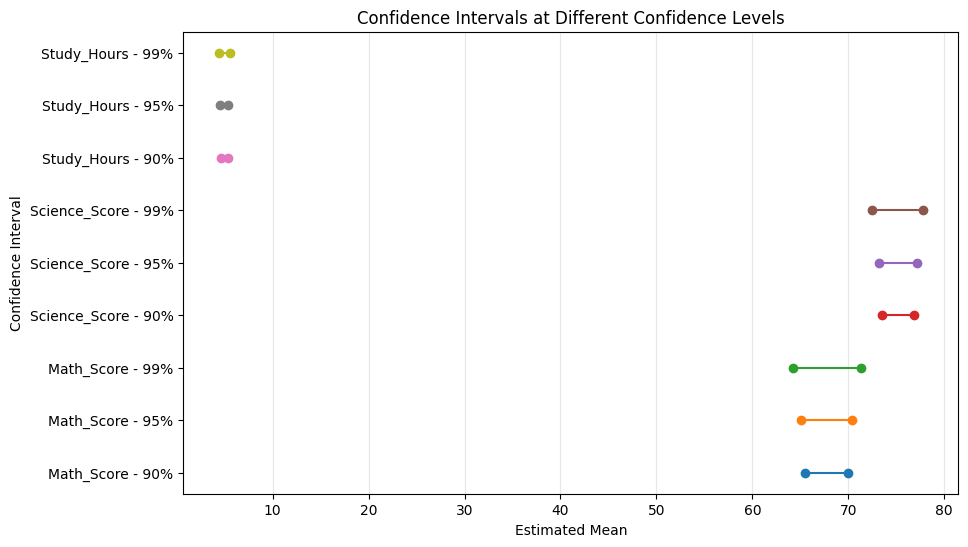

In [ ]:
plt.figure(figsize=(10, 6))

for column in data.columns:
    subset = results_df[results_df["Statistic"] == column]

    for _, row in subset.iterrows():
        confidence = row["Confidence Level"]
        lower = row["Lower Bound"]
        upper = row["Upper Bound"]

        plt.plot(
            [lower, upper],
            [f"{column} - {confidence}"] * 2,
            marker="o"
        )

plt.xlabel("Estimated Mean")
plt.ylabel("Confidence Interval")
plt.title("Confidence Intervals at Different Confidence Levels")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [ ]:
results_df["Interval Width"] = (
    results_df["Upper Bound"] - results_df["Lower Bound"]
)

results_df[["Statistic", "Confidence Level", "Interval Width"]]

,Statistic,Confidence Level,Interval Width
0,Math_Score,90%,4.43
1,Math_Score,95%,5.31
2,Math_Score,99%,7.07
3,Science_Score,90%,3.32
4,Science_Score,95%,3.98
5,Science_Score,99%,5.30
6,Study_Hours,90%,0.72
7,Study_Hours,95%,0.86
8,Study_Hours,99%,1.16


## Interpretation

Confidence intervals provide a range of plausible values for a population parameter based on sample data.

In this analysis, 90%, 95%, and 99% confidence intervals were calculated for the mean of Math Scores, Science Scores, and Study Hours.

The results show that higher confidence levels generally produce wider intervals.

The 90% confidence interval is narrower, while the 99% confidence interval is wider. This happens because greater confidence requires a larger range of possible values.

A 95% confidence interval means that if we repeatedly collected samples and calculated confidence intervals using the same method, approximately 95% of those intervals would contain the true population parameter.

Therefore, confidence intervals help communicate the uncertainty associated with estimates obtained from sample data.

## Interview Questions

### 1. What is a confidence interval?

A confidence interval is a range of values calculated from sample data that is used to estimate an unknown population parameter.

### 2. Why does increasing confidence usually widen an interval?

Increasing the confidence level requires a greater range of possible values to ensure that the interval captures the true population parameter more often. Therefore, the interval becomes wider.

### 3. What does a 95% confidence interval mean?

A 95% confidence interval means that if we repeatedly took samples and constructed intervals using the same method, approximately 95% of those intervals would contain the true population parameter.